Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

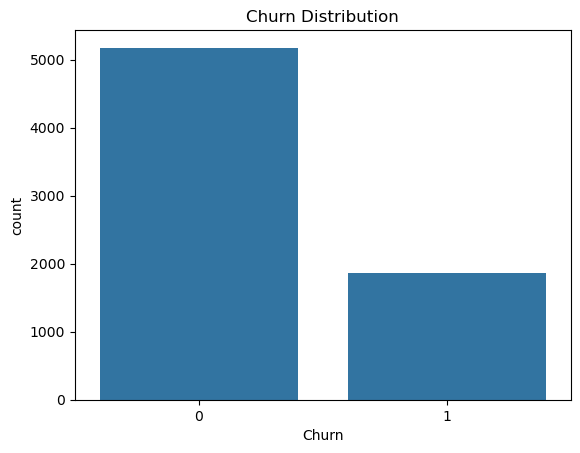

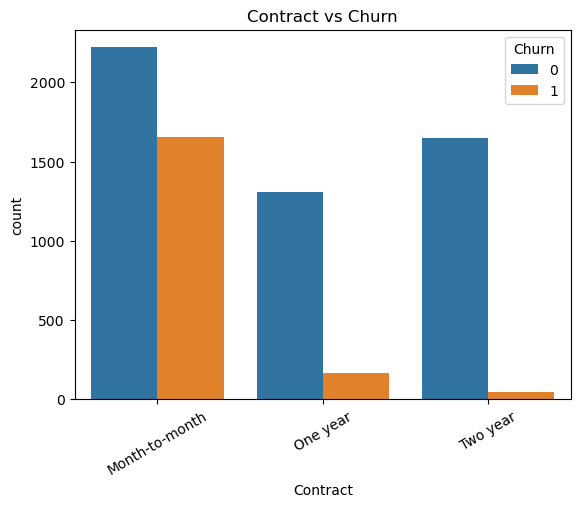

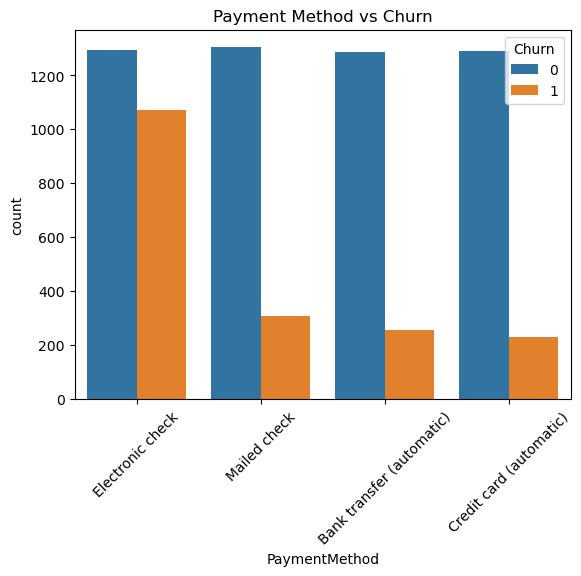

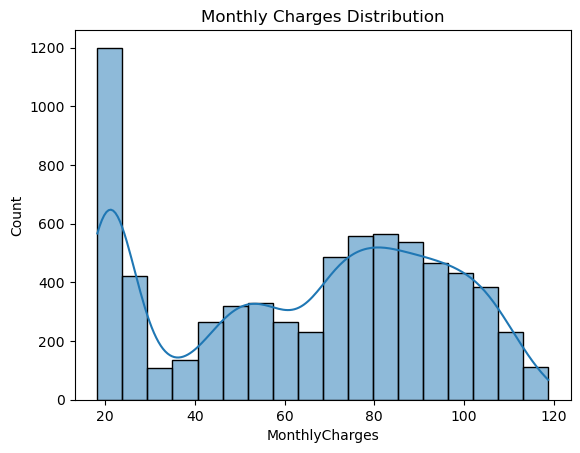

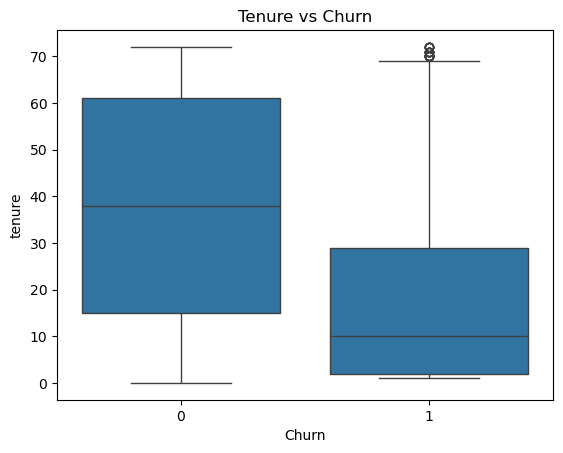

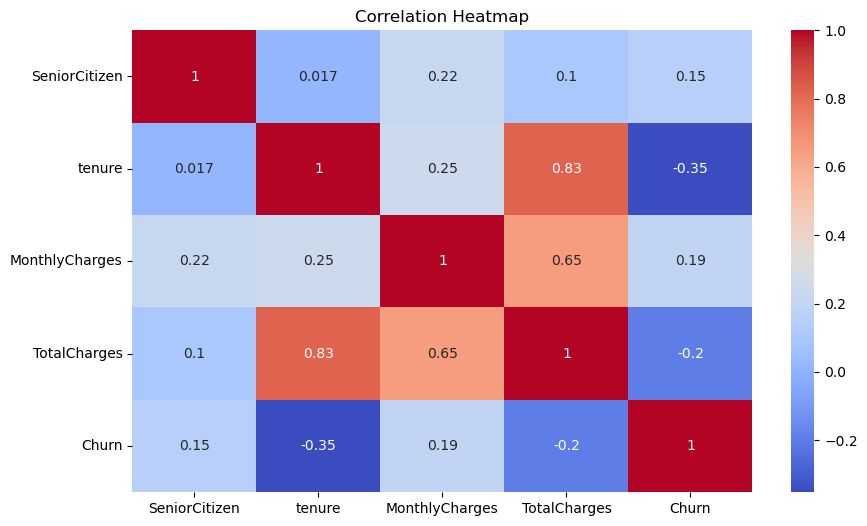


Logistic Regression Accuracy: 0.8126330731014905
Random Forest Accuracy: 0.7970191625266146

Random Forest Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



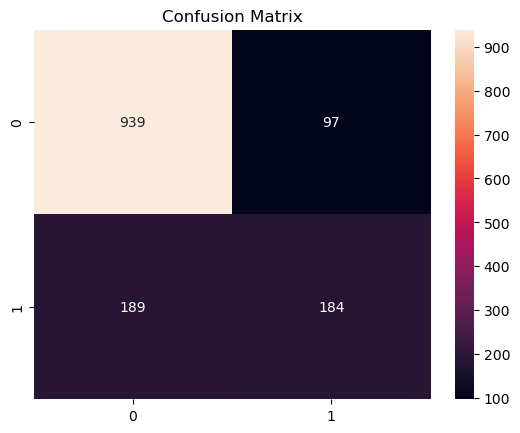

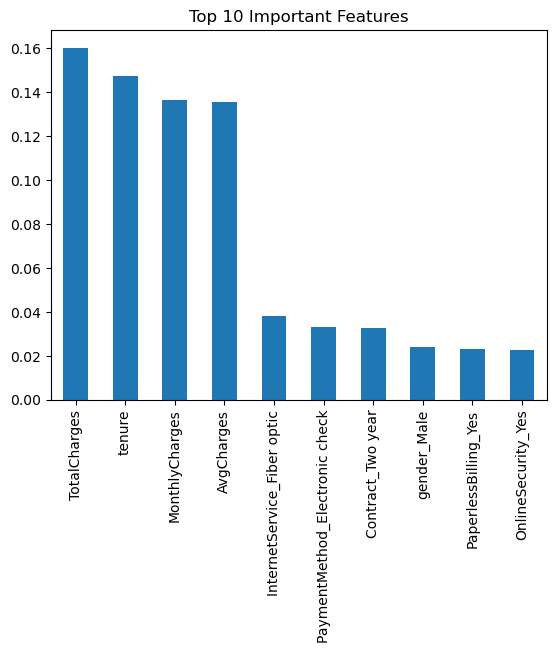


Key Insights:
- Month-to-month contracts increase churn risk
- High monthly charges → higher churn
- Longer tenure → lower churn
- Lack of tech support increases churn

Project Completed Successfully!


In [7]:
# =========================================
# CUSTOMER CHURN PREDICTION (ADVANCED)
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv('ccf-dataset.csv')

print("Shape:", df.shape)
print(df.head())

# -----------------------------
# Data Cleaning
# -----------------------------
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# -----------------------------
# Exploratory Data Analysis
# -----------------------------

# Churn distribution
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Contract vs Churn
plt.figure()
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.title("Contract vs Churn")
plt.show()

# Payment Method vs Churn
plt.figure()
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

# Monthly Charges
plt.figure()
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

# Tenure vs Churn
plt.figure()
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Feature Engineering
# -----------------------------
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

# -----------------------------
# Encoding
# -----------------------------
df = pd.get_dummies(df, drop_first=True)

# -----------------------------
# Split Data
# -----------------------------
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Models
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.show()

# -----------------------------
# Final Insights
# -----------------------------
print("\nKey Insights:")
print("- Month-to-month contracts increase churn risk")
print("- High monthly charges → higher churn")
print("- Longer tenure → lower churn")
print("- Lack of tech support increases churn")

print("\nProject Completed Successfully!")